In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
df_train = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/raw/train_FD001.txt", sep="\s+", header=None)
df_test = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/raw/test_FD001.txt", sep="\s+", header=None)
df_train.columns = ["engine_id", "cycle", "setting_1", "setting_2", "setting_3"] + [f"sensor_{i}" for i in range(1, 22)]
df_test.columns = ["engine_id", "cycle", "setting_1", "setting_2", "setting_3"] + [f"sensor_{i}" for i in range(1, 22)]


# 1. Exploratory Data Analysis (EDA)

The goal of this section is to understand the structure and behavior of the NASA Turbofan Engine dataset before building predictive models.

The EDA focuses on:

- Understanding the dataset structure
- Analyzing engine lifetimes
- Investigating sensor behavior over time
- Identifying useful sensors for predicting Remaining Useful Life (RUL)

### 1.1 Basic Structure Check

The dataset contains run-to-failure simulation data for multiple turbofan engines.

Each row represents a single operating cycle for a specific engine.

Key columns include:

- **engine_id**: unique identifier for each engine
- **cycle**: operating cycle number
- **setting_1, setting_2, setting_3**: operational settings
- **sensor_1 – sensor_21**: measurements from various engine sensors

Each engine begins operation in a healthy state and eventually degrades until failure.

In [4]:
df_train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [6]:
df_train.describe()


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [7]:
df_train.isnull().sum()

engine_id    0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64

In [8]:
df_train.nunique()

engine_id     100
cycle         362
setting_1     158
setting_2      13
setting_3       1
sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
dtype: int64

Only sensor 2, 3, 4, 7, 9, 11, 12, 14, 15, 20, 21 have over 100 unique values.

### 1.2 Enigine Life Time Analysis

To understand how long engines operate before failure, the maximum cycle for each engine was computed.

This represents the total lifetime of each engine.

The distribution of engine lifetimes shows that different engines fail at different cycles. This variability is important because it prevents the model from simply learning a fixed failure point.

Understanding the distribution of engine lifetimes helps contextualize the Remaining Useful Life (RUL) prediction problem.

In [9]:
engine_life = df_train.groupby("engine_id")["cycle"].max()
engine_life



engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

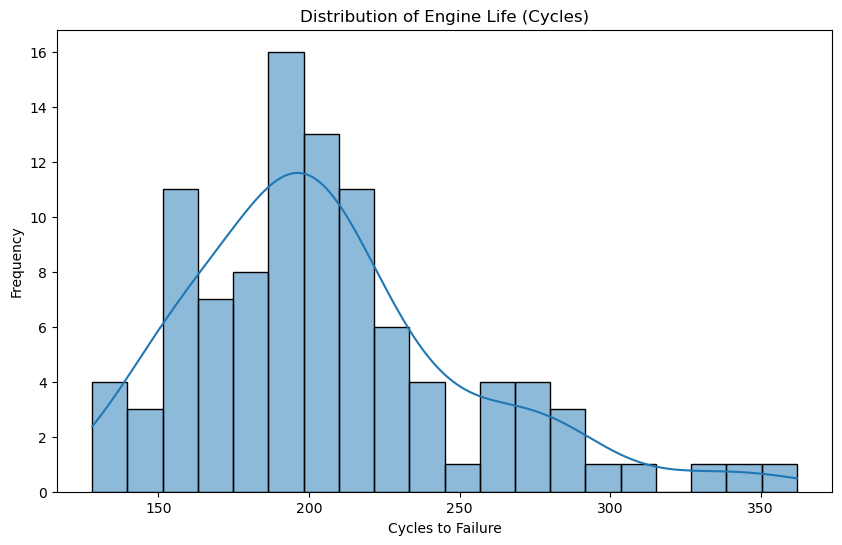

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(engine_life, bins=20, kde=True)
plt.title("Distribution of Engine Life (Cycles)")
plt.xlabel("Cycles to Failure")
plt.ylabel("Frequency")
plt.show()

### 1.3 Sensor Beahvior Over Time

Sensor measurements were visualized across operating cycles to observe degradation patterns.

Sensors with very low variability were excluded, leaving sensors with sufficient variation for analysis.

By plotting sensor values across cycles for a single engine, it becomes possible to visually inspect how sensors behave as the engine approaches failure.

Several sensors show clear monotonic trends over time, suggesting they capture information about engine degradation.

In [11]:

valid_sensors = [col for col in df_train.columns if col.startswith("sensor_") and df_train[col].nunique() > 100]
print("Valid Sensors:", valid_sensors)

Valid Sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_15', 'sensor_20', 'sensor_21']


To see the degradation trands. I picked engine 1

In [12]:
engine_1 = df_train[df_train["engine_id"] == 1]

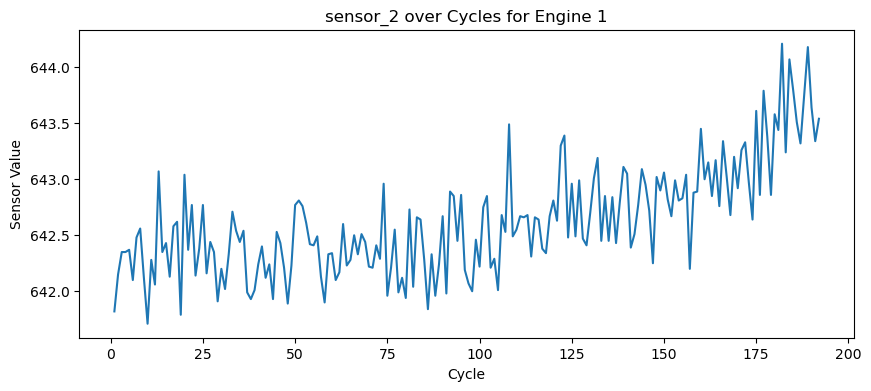

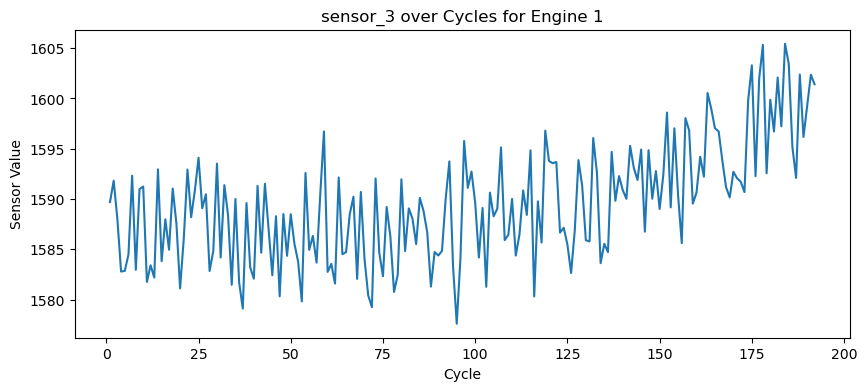

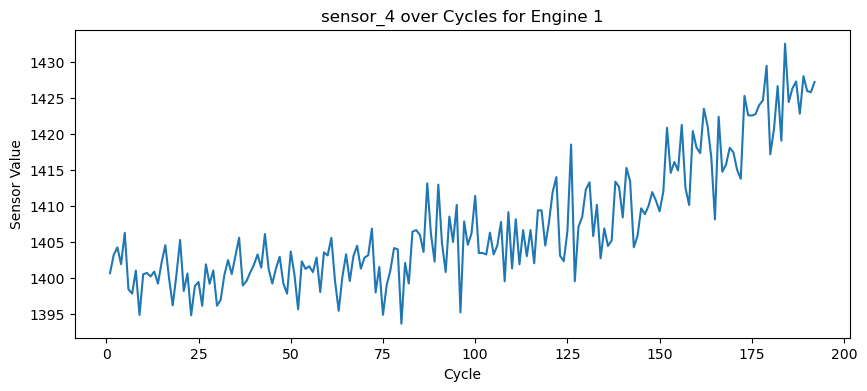

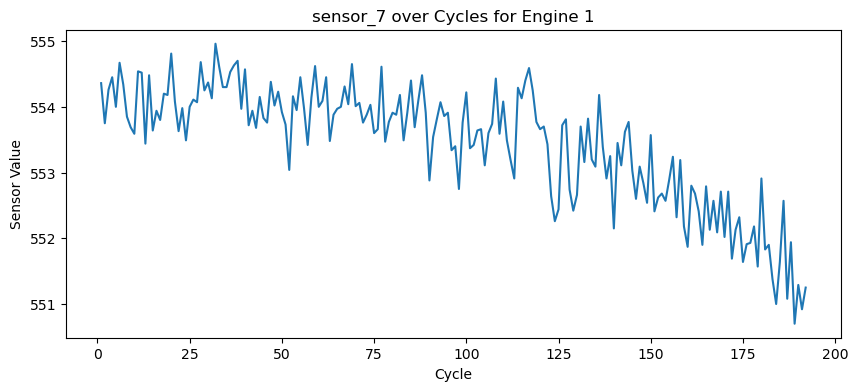

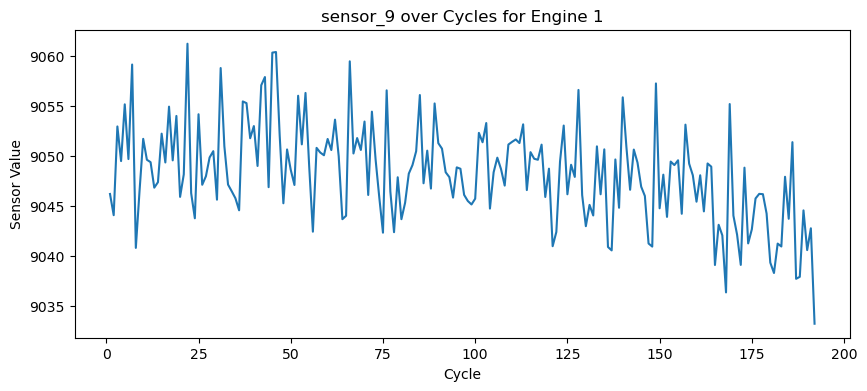

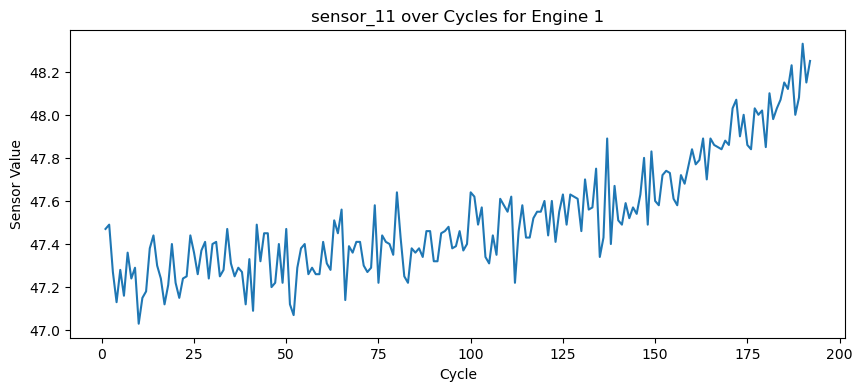

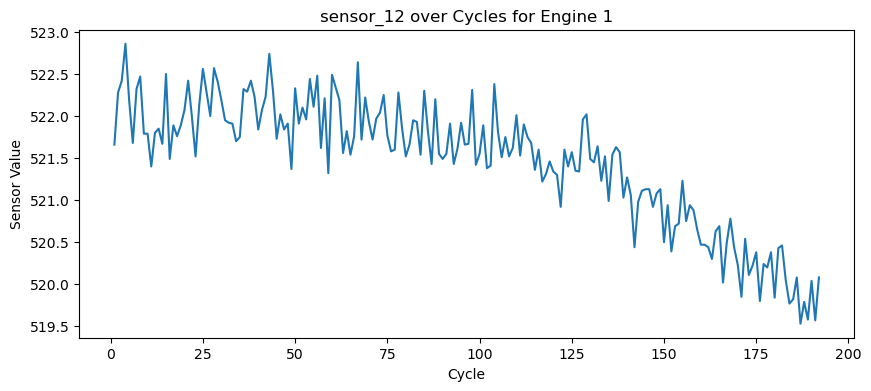

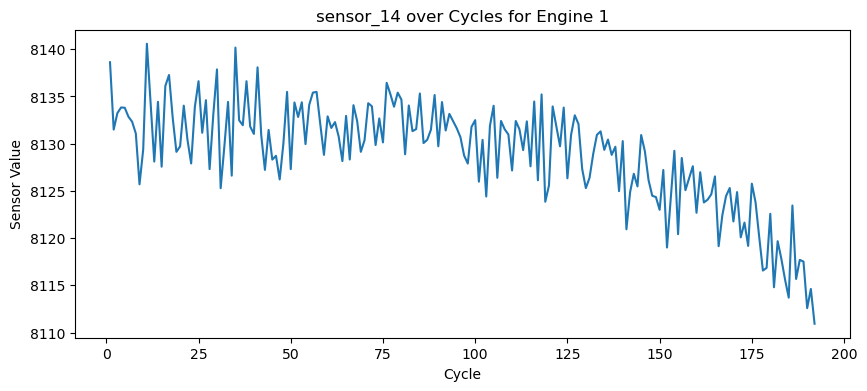

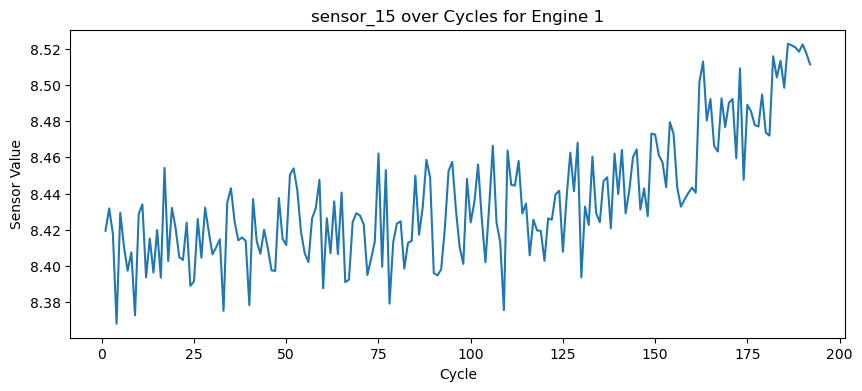

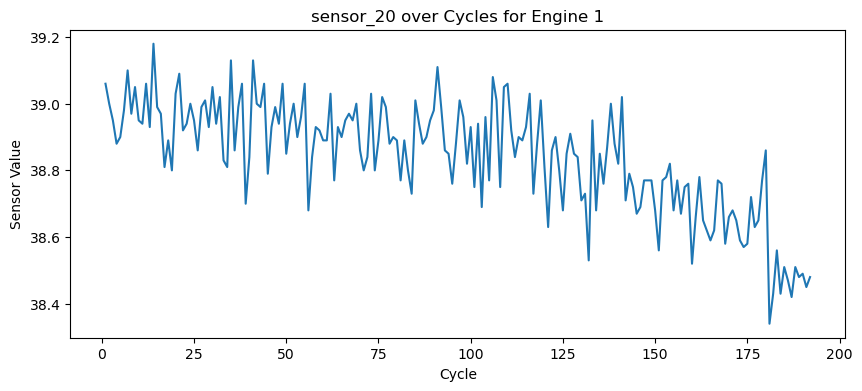

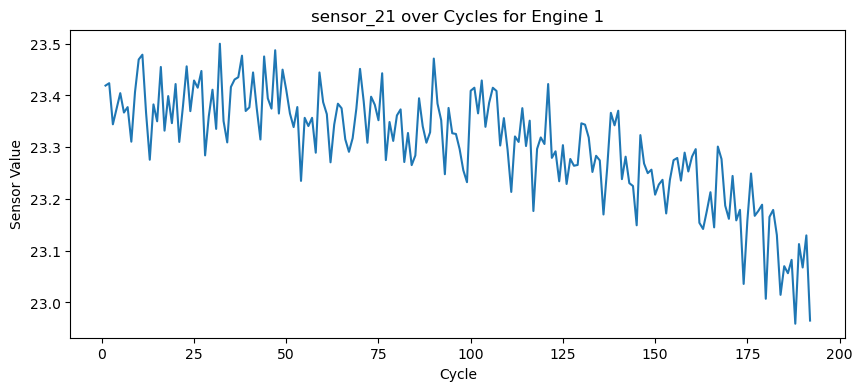

In [13]:
for sensor in valid_sensors:
    plt.figure(figsize=(10,4))
    plt.plot(engine_1["cycle"], engine_1[sensor])
    plt.title(f"{sensor} over Cycles for Engine 1")
    plt.xlabel("Cycle")
    plt.ylabel("Sensor Value")
    plt.show()

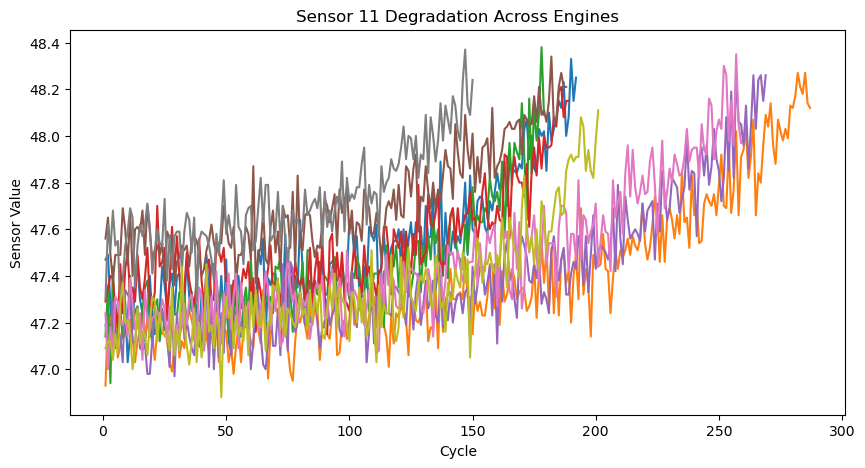

In [14]:
plt.figure(figsize=(10,5))

for engine in range(1,10):
    temp = df_train[df_train["engine_id"] == engine]
    plt.plot(temp["cycle"], temp["sensor_11"])

plt.title("Sensor 11 Degradation Across Engines")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.show()

Now. let's see the sensor 11 and RUL

The sensor 11 suddenly begin changing from 125 RUL.

### 1.4 Sensor Correlation Analysis

A correlation matrix was generated to examine relationships between sensors.

This analysis helps identify:

- Highly correlated sensors that may contain redundant information
- Sensors with little relationship to other variables

Understanding correlations is useful for feature selection and helps avoid including redundant features during modeling.

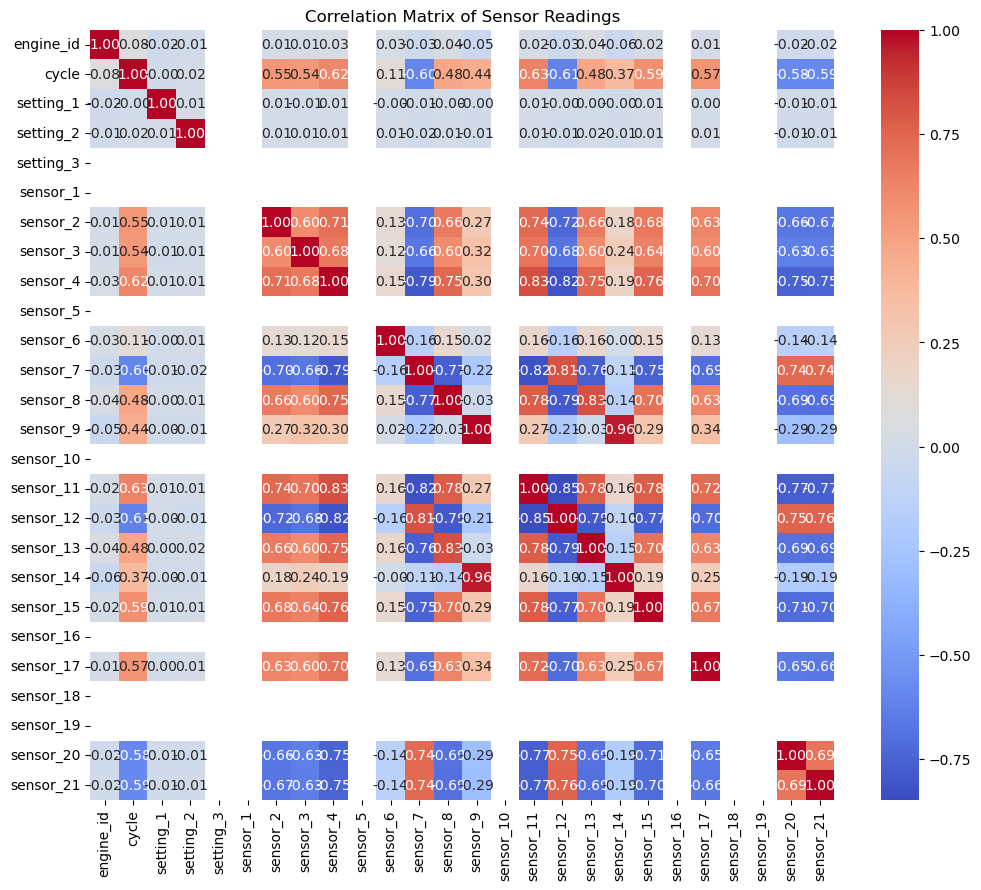

In [15]:
corr = df_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Sensor Readings")
plt.show()

### 1.5 Create Target Variable (RUL) 

The target variable for the predictive maintenance task is Remaining Useful Life (RUL).

RUL represents the number of cycles remaining before engine failure.

It is computed as:

RUL = max_cycle_for_engine − current_cycle

This transforms the run-to-failure dataset into a supervised learning problem where the model learns to predict how many cycles remain before failure.

In [16]:
max_cycle = df_train.groupby("engine_id")["cycle"].max()

df_train["RUL"] = df_train.apply(lambda row: max_cycle[row["engine_id"]] - row["cycle"], axis=1)
df_train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0


### 1.6 Feature Correlation with RUL

After computing the RUL target, the correlation between each feature and RUL was analyzed.

This helps identify sensors that are strongly associated with engine degradation.

Sensors with higher correlation with RUL are more likely to contain useful predictive information.

However, correlation alone does not fully determine feature usefulness because some sensors may have nonlinear relationships with RUL.

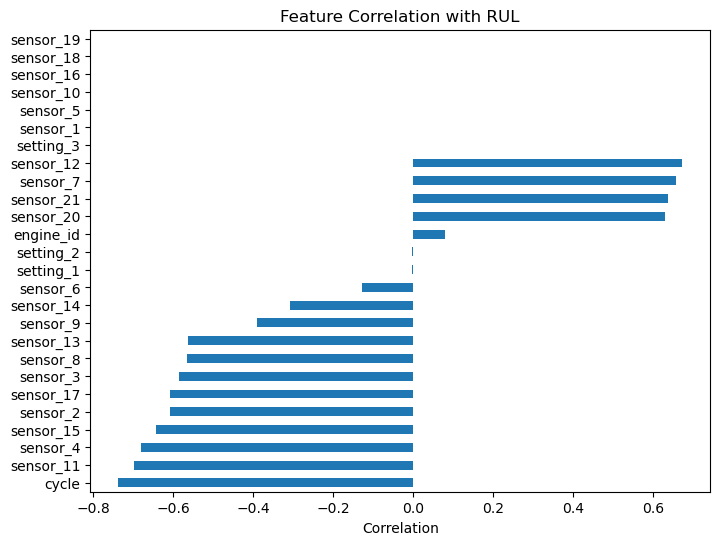

In [17]:
corr_rul = df_train.corr()["RUL"].drop("RUL").sort_values()

plt.figure(figsize=(8,6))
corr_rul.plot(kind="barh")
plt.title("Feature Correlation with RUL")
plt.xlabel("Correlation")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor

X = df_train.drop(columns=["RUL"])
y = df_train["RUL"]

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

cycle        0.542852
engine_id    0.181769
sensor_11    0.142528
sensor_9     0.031503
sensor_12    0.017071
sensor_14    0.016497
sensor_4     0.015159
sensor_7     0.009941
sensor_13    0.006491
sensor_15    0.006142
sensor_8     0.005888
sensor_21    0.005646
sensor_2     0.004524
sensor_20    0.003964
sensor_3     0.003953
setting_1    0.002765
setting_2    0.001795
sensor_17    0.001411
sensor_6     0.000100
sensor_1     0.000000
sensor_10    0.000000
sensor_16    0.000000
sensor_18    0.000000
sensor_19    0.000000
sensor_5     0.000000
setting_3    0.000000
dtype: float64

Based on correlation, Random Forest feature importance, and degradiation trand, these are the strong baseline data set :

sensor_2, sensor_3, sensor_4, sensor_7, sensor_8, sensor_9, sensor_11, sensor_12, sensor_13, sensor_14, sensor_15, sensor_20, sensor_21


### 1.7 Sensor Degradation vs Remaining Useful Life

To better understand degradation behavior, average sensor values were plotted against Remaining Useful Life (RUL).

Unlike cycle-based plots, aligning data by RUL allows engines with different lifetimes to be compared at the same stage of degradation.

The results show that several sensors remain relatively stable when RUL is high (healthy engines) and change more rapidly as RUL approaches zero.

This confirms that these sensors capture the degradation process and are suitable inputs for predicting engine failure.

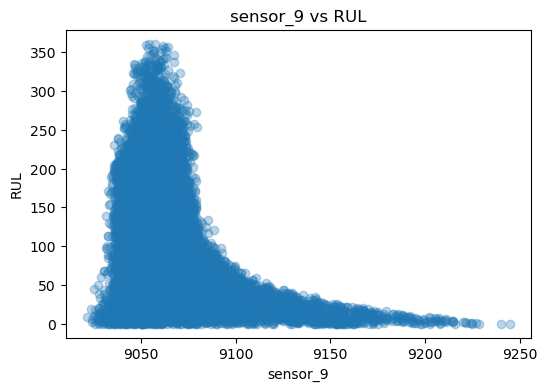

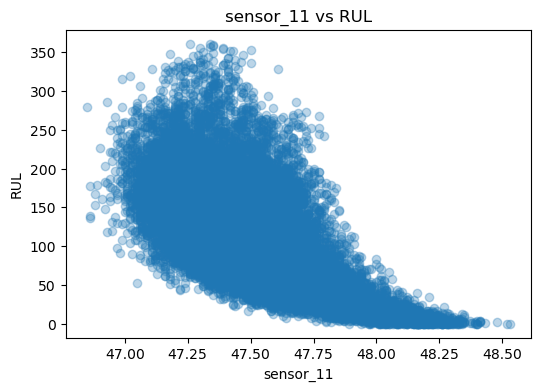

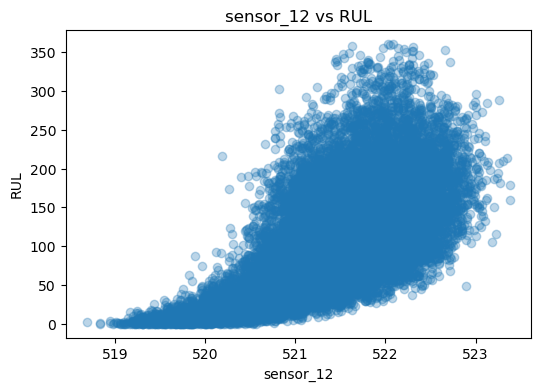

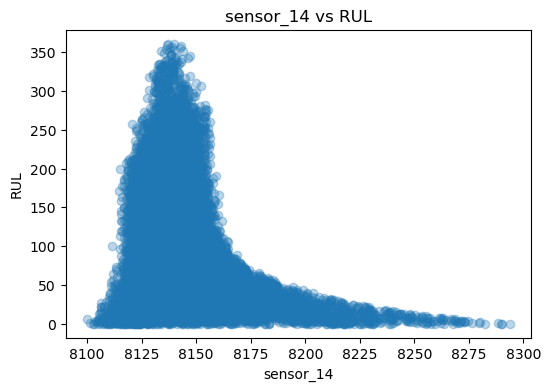

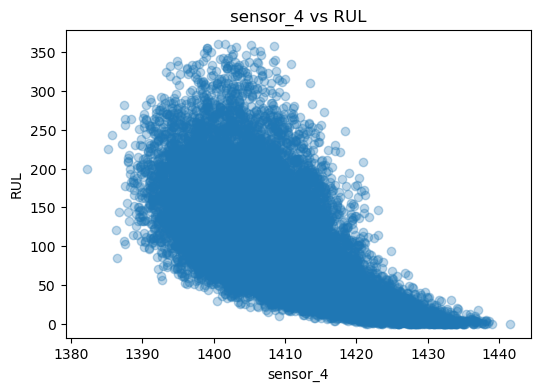

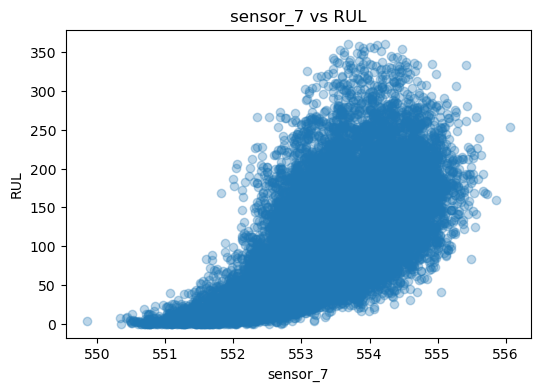

In [19]:
important_sensors = ["sensor_9","sensor_11","sensor_12","sensor_14","sensor_4","sensor_7"]

for sensor in important_sensors:
    plt.figure(figsize=(6,4))
    plt.scatter(df_train[sensor], df_train["RUL"], alpha=0.3)
    plt.xlabel(sensor)
    plt.ylabel("RUL")
    plt.title(f"{sensor} vs RUL")
    plt.show()

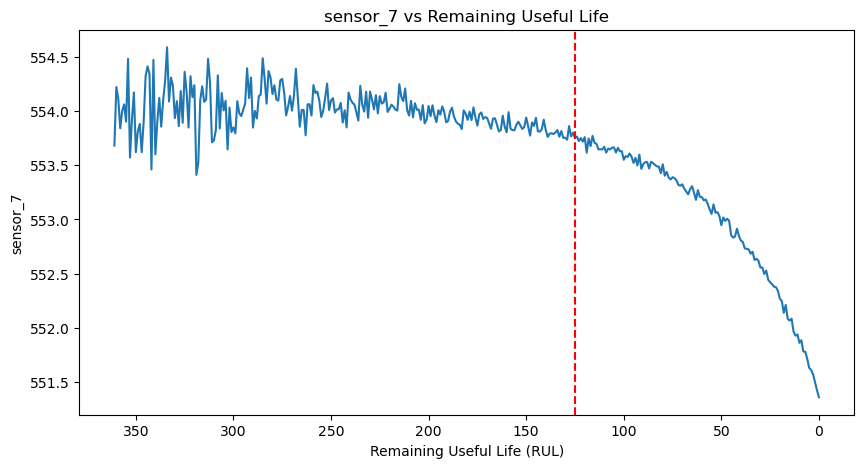

In [20]:
ensor = "sensor_11"

sensor_trend = df_train.groupby("RUL")[sensor].mean()

plt.figure(figsize=(10,5))
plt.plot(sensor_trend)
plt.axvline(125, color="red", linestyle="--", label="Typical degradation start")
plt.xlabel("Remaining Useful Life (RUL)")
plt.ylabel(sensor)
plt.title(f"{sensor} vs Remaining Useful Life")
plt.gca().invert_xaxis()
plt.show()

### 1.8 Key Insights from EDA

The exploratory analysis revealed several important characteristics of the dataset:

1. Engine lifetimes vary significantly across units, indicating that failure does not occur at a fixed cycle.

2. Several sensors exhibit clear degradation patterns as engines approach failure.

3. Some sensors show very low variability and likely contain little predictive information.

4. Aligning sensor values by Remaining Useful Life (RUL) reveals clearer degradation trends than aligning by cycle.

5. The dataset provides strong signals that can be used to predict engine health and remaining lifetime.

These findings guide the feature selection and feature engineering steps used in the modeling stage.

### 1.9 Feature Selection Summary

Based on the exploratory analysis, sensors were evaluated using multiple criteria:

- Variability of sensor values
- Visual degradation trends over time
- Correlation with Remaining Useful Life (RUL)
- Model-based feature importance

Sensors that showed very low variability or no predictive signal were removed to reduce noise and improve model performance. 

| Feature | Decision | Reason |
|-------|-------|-------|
| engine_id | Removed | Identifier only, not a predictive feature |
| cycle | Removed | Directly related to RUL calculation and may cause leakage |
| sensor_1 | Removed | Very low variance |
| sensor_5 | Removed | Very low variance |
| sensor_6 | Removed | Very low variance |
| sensor_10 | Removed | Very low variance |
| sensor_16 | Removed | Very low variance |
| sensor_18 | Removed | Very low variance |
| sensor_19 | Removed | Very low variance |
| sensor_2 | Kept | Shows degradation trend and useful variability |
| sensor_3 | Kept | Shows degradation trend |
| sensor_4 | Kept | Moderate correlation with RUL |
| sensor_7 | Kept | Useful variation across cycles |
| sensor_8 | Kept | Contributes predictive information |
| sensor_9 | Kept | Known degradation indicator |
| sensor_11 | Kept | Strong correlation with RUL |
| sensor_12 | Kept | Strong degradation signal |
| sensor_13 | Kept | Useful predictive signal |
| sensor_14 | Kept | Captures degradation behavior |
| sensor_15 | Kept | Shows degradation near failure |
| sensor_20 | Kept | Contributes to model prediction |
| sensor_21 | Kept | Useful sensor variability |

### Final Feature Set

After removing non-informative variables, the final feature set used for modeling includes:

sensor_2, sensor_3, sensor_4, sensor_7, sensor_8, sensor_9, sensor_11, sensor_12, sensor_13, sensor_14, sensor_15, sensor_20, sensor_21

These sensors provide sufficient variability and capture degradation patterns useful for predicting Remaining Useful Life.

In [24]:
selected_sensors = [
    "sensor_2","sensor_3","sensor_4","sensor_7","sensor_8",
    "sensor_9","sensor_11","sensor_12","sensor_13",
    "sensor_14","sensor_15","sensor_20","sensor_21"
]

In [23]:
df_train.to_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/processed/train_after_eda.csv", index=False)